# This notebook shows how to reproduce the figures in Chapter 4

## Load packages needed to run this notebook

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from glob import glob
import re
import os
from scipy import stats
from scipy.stats import chisquare

## Get the status for each gid

In [3]:
# extract the gid from GENCODE because we are classifying at gene level
mapping = []

with open("/home/chiga034/projects_limgroup/dotseq/ref/gencode.v47.annotation.gtf") as f:
    for line in f:
        if line.startswith("#"):
            continue
        fields = line.strip().split("\t")
        if fields[2] == "transcript":
            attr = fields[8]

            tid = attr.split('transcript_id "')[1].split('"')[0]
            gid = attr.split('gene_id "')[1].split('"')[0]

            mapping.append((tid, gid))

df_map = pd.DataFrame(mapping, columns=["tid", "gid"])

In [4]:
# Annotated uORFs from GENCODE
gen = pd.read_csv('/home/chiga034/projects_limgroup/dotseq/ref/gencode.v47.annotation.orf_finder.txt', sep='\t')
gen = gen[gen.start_codon=='ATG']
gen =gen[['Chromosome','Start','End','tid','ORF_type','Strand']]
gen = gen.rename(columns={ 'Chromosome': 'chr',
                         'Start': 'orf_start',
                         'End': 'orf_end',
                         'tid': 'tid',
                         'ORF_type': 'orf_type',
                         'Strand': 'strand'})
gen = gen.sort_values(['chr','orf_start']).reset_index(drop=True)

gen_temp = pd.merge(gen,df_map, how='inner',on='tid')
gen_temp = gen_temp.drop(columns=['tid'])

orf_sets = gen_temp.groupby("gid")["orf_type"].apply(set)

def combo_name(s):
    return "_".join(sorted(s)) if s else "none"

gen_temp["status"] = gen_temp["gid"].map(orf_sets.apply(combo_name))

# remove gid that does not have mORF
gen_temp = gen_temp[gen_temp.status.str.contains('mORF')]
gen_temp2 = gen_temp[['gid','status']]

## Results section 4.4.1 Additional ORFs reshape mORF translational activity

### Number of actively translated orfs

In [ ]:
def combo_name(s):
    return "_".join(sorted(s)) if s else "none"

# MCI results from DOTSeq
dot_mci = pd.read_csv('../../chapter3/dotseq_results_mc_vs_inter.csv')
dot_mci = dot_mci.rename(columns={'start':'orf_start','end':'orf_end'})
dot_mci['contrast'] = 'mci'
gr = dot_mci[['chr','orf_start','orf_end','orf_id','strand','orf_type']].copy()

# obtain gid from orf_id to group them into different orf compositions
dot_mci['gid'] = dot_mci.orf_id.str.split(':').str[0]
# orf_sets = dot_mci.groupby('gid')['orf_type'].apply(set)
# dot_mci["status"] = dot_mci['gid'].map(orf_sets.apply(combo_name))

dot_mci = pd.merge(dot_mci,gen_temp2, on=['gid'])

# Combine the orf compositions and orf type into one column 
dot_mci['misc'] = dot_mci['contrast'] + ',' + dot_mci['orf_type'] + ',' + dot_mci['status']
# remove gid that does not have mORF
dot_mci = dot_mci[dot_mci.status.str.contains('mORF')]


dot_mai = pd.read_csv('../../chapter3/dotseq_results_ma_vs_inter.csv')
dot_mai = dot_mai.rename(columns={'start':'orf_start','end':'orf_end'})
dot_mai['contrast'] = 'mai'
dot_mai = pd.merge(dot_mai,gr, on='orf_id')
dot_mai['contrast'] = 'mai'

# obtain gid from orf_id to group them into different orf compositions
dot_mai['gid'] = dot_mai.orf_id.str.split(':').str[0]
# orf_sets = dot_mai.groupby('gid')['orf_type'].apply(set)
# dot_mai["status"] = dot_mai['gid'].map(orf_sets.apply(combo_name))

dot_mai = pd.merge(dot_mai,gen_temp2, on=['gid'])
# Combine the orf compositions and orf type into one column 
dot_mai['misc'] = dot_mai['contrast'] + ',' + dot_mai['orf_type'] + ',' + dot_mai['status']
# remove gid that does not have mORF
dot_mai = dot_mai[dot_mai.status.str.contains('mORF')]

dot = pd.concat([dot_mci,dot_mai]).reset_index(drop=True)

In [33]:
dot[(dot.baseMean!=0) & (~dot.status.str.contains('oORF'))].groupby(['status'])['gid'].nunique()

status
dORF_mORF         6241
dORF_mORF_uORF    8722
mORF               686
mORF_uORF          517
Name: gid, dtype: int64

In [12]:
print(f"Total number of genes that contains actively translated ORFs: {dot[(dot.baseMean!=0) & (~dot.status.str.contains('oORF'))].groupby(['status'])['gid'].nunique().sum()}")

Total number of genes that contains actively translated ORFs: 16166


### Differentially translated orfs

In [5]:
def combo_name(s):
    return "_".join(sorted(s)) if s else "none"

# MCI results from DOTSeq
dot_mci = pd.read_csv('../../chapter3/dotseq_results_mc_vs_inter.csv')
dot_mci = dot_mci.rename(columns={'start':'orf_start','end':'orf_end'})
dot_mci['contrast'] = 'mci'
gr = dot_mci[['chr','orf_start','orf_end','orf_id','strand','orf_type']].copy()
dot_mci = dot_mci[dot_mci['padj'] < 0.05]

# obtain gid from orf_id to group them into different orf compositions
dot_mci['gid'] = dot_mci.orf_id.str.split(':').str[0]
# orf_sets = dot_mci.groupby('gid')['orf_type'].apply(set)
# dot_mci["status"] = dot_mci['gid'].map(orf_sets.apply(combo_name))

dot_mci = pd.merge(dot_mci,gen_temp2, on=['gid'])

# Combine the orf compositions and orf type into one column 
dot_mci['misc'] = dot_mci['contrast'] + ',' + dot_mci['orf_type'] + ',' + dot_mci['status']
# remove gid that does not have mORF
dot_mci = dot_mci[dot_mci.status.str.contains('mORF')]


dot_mai = pd.read_csv('../../chapter3/dotseq_results_ma_vs_inter.csv')
dot_mai = dot_mai.rename(columns={'start':'orf_start','end':'orf_end'})
dot_mai['contrast'] = 'mai'
dot_mai = pd.merge(dot_mai,gr, on='orf_id')
dot_mai['contrast'] = 'mai'
dot_mai = dot_mai[dot_mai['padj'] < 0.05]

# obtain gid from orf_id to group them into different orf compositions
dot_mai['gid'] = dot_mai.orf_id.str.split(':').str[0]
# orf_sets = dot_mai.groupby('gid')['orf_type'].apply(set)
# dot_mai["status"] = dot_mai['gid'].map(orf_sets.apply(combo_name))

dot_mai = pd.merge(dot_mai,gen_temp2, on=['gid'])
# Combine the orf compositions and orf type into one column 
dot_mai['misc'] = dot_mai['contrast'] + ',' + dot_mai['orf_type'] + ',' + dot_mai['status']
# remove gid that does not have mORF
dot_mai = dot_mai[dot_mai.status.str.contains('mORF')]

dot = pd.concat([dot_mci,dot_mai]).reset_index(drop=True)

In [6]:
#filter before merging so less messy
dot_fil = dot[['contrast','gid','status','orf_id','orf_type','orf_start','orf_end','posterior','log2FoldChange','lfsr','padj']]
dot_fil = dot_fil[~dot_fil.status.str.contains('oORF')]

In [19]:
print(f"Number of genes that contain differentially translated orf(s) for MCI: {dot_fil[dot_fil.contrast=='mci'].groupby(['status'])['gid'].nunique().sum()}")
print(f"Number of genes that contain differentially translated orf(s) for MAI: {dot_fil[dot_fil.contrast=='mai'].groupby(['status'])['gid'].nunique().sum()}")

Number of genes that contain differentially translated orf(s) for MCI: 2950
Number of genes that contain differentially translated orf(s) for MAI: 4850


### Table 4.1

In [57]:
dot_fil2 = dot_fil.groupby(['contrast','status'])['gid'].nunique().reset_index(name='gene_counts')

# Pivot
wide = (
    dot_fil2.pivot(index="status", columns="contrast", values="gene_counts")
      .reset_index()
)

# Rename statuses
wide["status"] = wide["status"].replace({
    "mORF_uORF": "uORF_mORF",
    "dORF_mORF": "mORF_dORF",
    "dORF_mORF_uORF": "uORF_mORF_dORF"
})

order = [
    "mORF",
    "uORF_mORF",
    "mORF_dORF",
    "uORF_mORF_dORF"
]

wide["status"] = pd.Categorical(
    wide["status"],
    categories=order,
    ordered=True
)

# Sort and reorder columns
wide = (
    wide.sort_values("status")
        .reset_index(drop=True)[["status", "mci", "mai"]]
)

gencode_ref_gene_counts = gen_temp2[~gen_temp2.status.str.contains('oORF')].drop_duplicates('gid').status.value_counts().reset_index(name='gene_counts')
gencode_ref_gene_counts["status"] = gencode_ref_gene_counts["status"].replace({
    "mORF_uORF": "uORF_mORF",
    "dORF_mORF": "mORF_dORF",
    "dORF_mORF_uORF": "uORF_mORF_dORF"
})

table_4_1 = pd.merge(wide, gencode_ref_gene_counts, on='status')
table_4_1 = table_4_1.rename(columns={'gene_counts':'gencode'})
table_4_1

,status,mci,mai,gencode
0,mORF,83,165,1260
1,uORF_mORF,73,130,678
2,mORF_dORF,1005,1876,7500
3,uORF_mORF_dORF,1789,2679,9807


In [59]:
# To compare the distributions with GENCODE

# GENCODE proportions
gencode_prop = table_4_1['gencode'] / table_4_1['gencode'].sum()

# MCI
obs_mci = table_4_1['mci']
exp_mci = gencode_prop * obs_mci.sum()

chi2_mci, p_mci = chisquare(obs_mci, f_exp=exp_mci)

# MAI
obs_mai = table_4_1['mai']
exp_mai = gencode_prop * obs_mai.sum()

chi2_mai, p_mai = chisquare(obs_mai, f_exp=exp_mai)

print(f"MCI: χ²={chi2_mci:.2f}, p={p_mci:.3e}")
print(f"MAI: χ²={chi2_mai:.2f}, p={p_mai:.3e}")

MCI: χ²=144.52, p=4.011e-31
MAI: χ²=100.58, p=1.169e-21


### Table 4.2

In [17]:
table_4_2 = dot_fil.groupby(['orf_type','contrast'])['log2FoldChange'].agg(['mean', 'std']).round(3).reset_index()

orf_order = [
    "uORF",
    "mORF",
    "dORF"
]

contrast_order = ['mci','mai']

table_4_2["orf_type"] = pd.Categorical(
    table_4_2["orf_type"],
    categories=orf_order,
    ordered=True
)

table_4_2["contrast"] = pd.Categorical(
    table_4_2["contrast"],
    categories=contrast_order,
    ordered=True
)

table_4_2 = table_4_2.sort_values(["orf_type", "contrast"]).reset_index(drop=True)

table_4_2

,orf_type,contrast,mean,std
0,uORF,mci,1.043,0.749
1,uORF,mai,1.165,0.984
2,mORF,mci,-0.848,1.022
3,mORF,mai,-0.749,1.401
4,dORF,mci,-1.073,0.506
5,dORF,mai,1.334,0.375


### Table 4.3

In [7]:
orfs_main = ['mORF_uORF', 'dORF_mORF', 'dORF_mORF_uORF']
value_cols = ['posterior', 'log2FoldChange']
cont =['mci','mai']
results = []

for c in cont:
    for v in value_cols:
        g1 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']=='dORF_mORF_uORF') & (dot_fil.orf_type=='uORF')][v].dropna()
        g2 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']=='mORF_uORF') & (dot_fil.orf_type=='uORF')][v].dropna()
        
        t_stat, t_pval = stats.ttest_ind(g1, g2) 
    
        results.append({
                'contrast': c,
                'pair': f'dORF_mORF_uORF|mORF_uORF',
                'mod':v,
                'orf_type': 'uORF',
                'n_diff': len(g1),
                'n_diff_ss': len(g2),
                't_stat': t_stat,
                'p_value': t_pval
            })

for c in cont:
    for v in value_cols:
        for s in orfs_main:
            g1 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']==s) & (dot_fil.orf_type=='mORF')][v].dropna()
            g2 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']=='mORF') & (dot_fil.orf_type=='mORF')][v].dropna()
            
            t_stat, t_pval = stats.ttest_ind(g1, g2) 
        
            results.append({
                    'contrast': c,
                    'pair': f'{s}|mORF',
                    'orf_type': 'mORF',
                    'mod':v,
                    'n_diff': len(g1),
                    'n_diff_ss': len(g2),
                    't_stat': t_stat,
                    'p_value': t_pval
                })
        
for c in cont:
    for v in value_cols:
        g1 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']=='dORF_mORF_uORF') & (dot_fil.orf_type=='dORF')][v].dropna()
        g2 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']=='dORF_mORF') & (dot_fil.orf_type=='dORF')][v].dropna()
        
        t_stat, t_pval = stats.ttest_ind(g1, g2) 
    
        results.append({
                'contrast': c,
                'pair': f'dORF_mORF_uORF|mORF_dORF',
                'mod':v,
                'orf_type': 'dORF',
                'n_diff': len(g1),
                'n_diff_ss': len(g2),
                't_stat': t_stat,
                'p_value': t_pval
            })

In [12]:
df_stats_orf = pd.DataFrame(results)
df_stats_orf_fil = df_stats_orf[(df_stats_orf['mod']=='log2FoldChange') & (df_stats_orf.p_value<0.05)][['contrast','orf_type','pair','t_stat','p_value']]

orf_order = ["uORF","mORF","dORF"]

contrast_order = ['mci','mai']

df_stats_orf_fil["orf_type"] = pd.Categorical(
    df_stats_orf_fil["orf_type"],
    categories=orf_order,
    ordered=True
)

df_stats_orf_fil["contrast"] = pd.Categorical(
    df_stats_orf_fil["contrast"],
    categories=contrast_order,
    ordered=True
)

df_stats_orf_fil["pair"] = df_stats_orf_fil["pair"].replace({"dORF_mORF_uORF|mORF_uORF": "uORF_mORF vs uORF_mORF_dORF",
                                                             "mORF_uORF|mORF": "uORF_mORF vs mORF",
                                                             "dORF_mORF|mORF": "mORF_dORF vs mORF",
                                                             "dORF_mORF_uORF|mORF":"uORF_mORF_dORF vs mORF"})

table_4_3 = df_stats_orf_fil.sort_values(["orf_type", "contrast"]).reset_index()

table_4_3

### Figure 4.2

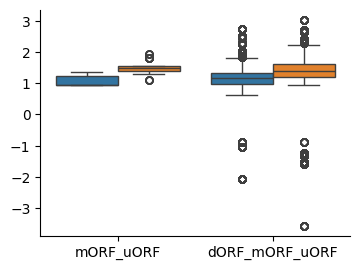

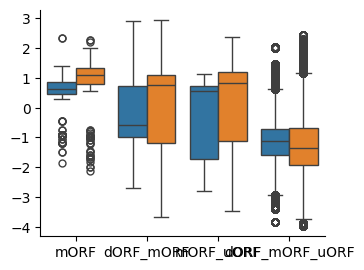

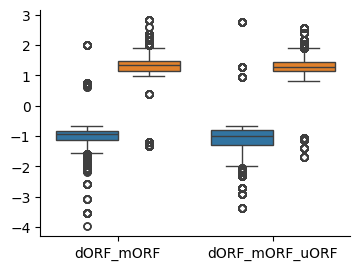

In [12]:
g = sns.catplot(dot_fil[dot_fil.orf_type=='uORF'], y='log2FoldChange', x='status', hue='contrast', hue_order=['mci','mai'], legend=False,
                order=['mORF_uORF', 'dORF_mORF_uORF'], kind='box', height=3, aspect=1.3)

for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    
# plt.savefig("figures/transcript_types_dte_uORF.png", dpi=300)
# plt.savefig("figures/transcript_types_dte_uORF.pdf")

g = sns.catplot(dot_fil[dot_fil.orf_type=='mORF'], y='log2FoldChange', x='status', hue='contrast', hue_order=['mci','mai'], legend=False,
                order=['mORF', 'dORF_mORF', 'mORF_uORF', 'dORF_mORF_uORF'], kind='box', height=3, aspect=1.3)

for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')

# plt.savefig("figures/transcript_types_dte_mORF.png", dpi=300)
# plt.savefig("figures/transcript_types_dte_mORF.pdf")

g = sns.catplot(dot_fil[dot_fil.orf_type=='dORF'], y='log2FoldChange', x='status', hue='contrast', hue_order=['mci','mai'], legend=False,
                order=['dORF_mORF', 'dORF_mORF_uORF'], kind='box', height=3, aspect=1.3)

for ax in g.axes.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('')
    
# plt.savefig("figures/transcript_types_dte_dORF.png", dpi=300)
# plt.savefig("figures/transcript_types_dte_dORF.pdf")

## Results section 4.4.2

In [18]:
# prepare bed file from DOTSeq output to intercept with splice sites
bed = dot[['chr','orf_start','orf_end','orf_id','misc','strand']]
bed = bed.sort_values(['chr', 'orf_start', 'orf_end']).reset_index(drop=True)
# bed.to_csv('ly_dou_dte_combined_diff_only_reanalysed.bed', sep="\t", index=None, header=None)

# Prepare splice site files (renaming for consistency)
sb = pd.read_csv('/home/chiga034/projects_limgroup/gab/2026/rna_llm/results_hg38/ss_predicted.bed', header=None, sep='\t')
sb = sb[[0,1,2,3,5,4]]
# sb.to_csv('ss_predicted.bed', sep="\t", index=None, header=None)

# Bedtools windows to get splice sites located +/- 100 nucleotides around ORF start codon
# ! bedtools window -a ly_dou_dte_combined_diff_only_reanalysed.bed -b ../ss_predicted.bed -w 100 > combined_window_diff_only_reanalysed.bed

In [22]:
df = pd.read_csv('../../chapter3/gene_level/combined_window_diff_only_reanalysed.bed',sep='\t',header=None)
df = df[[0,1,2,9,4,3,10,7,8]]
df = df.rename(columns={0: 'chr', 1: 'orf_start',
                        2: 'orf_end', 3: 'orf_id', 9:'gid',
                        4: 'misc', 10:'region',7:'ss_start',8:'ss_end'})
df = df.sort_values(['chr','orf_start','orf_end'])
df['ss_type'] = df.region.str.split('_').str[0].str.split('(').str[1]
df['region'] = df.region.str.split('_').str[1].str.split(')').str[0]

df['ss_pos'] = np.where(df['ss_type'] == 'acceptor',df['ss_end'] - df['orf_start'],df['ss_start'] - df['orf_start'])
df = df[
    ((df['ss_type'] == 'acceptor') & (df['ss_pos'] <= 0)) |
    ((df['ss_type'] == 'donor') & (df['ss_pos'] >= 0))
]
df['abs_ss_pos'] = df['ss_pos'].abs()
df['orf_length'] = df['orf_end'] - df['orf_start']

df['contrast'] = df.misc.str.split(',').str[0]
df['orf_type'] = df.misc.str.split(',').str[1]
df['status'] = df.misc.str.split(',').str[2]
df = df[['contrast', 'chr','gid','status','orf_id','orf_type','orf_start','orf_end','orf_length', 'region','ss_type','ss_start','ss_end','ss_pos','abs_ss_pos']]
df_all = df.copy()
df = df[df.abs_ss_pos<=100]

In [27]:
dot_fil['has_ss'] = dot_fil['orf_id'].isin(df['orf_id']).astype(int)

dot_fil['state'] = np.select(
    [
        # differential + splice site
        (dot_fil['padj'] < 0.05) & (dot_fil['has_ss'] == 1),

        # differential no splice site
        (dot_fil['padj'] < 0.05) & (dot_fil['has_ss'] == 0),
    ],
    [
        'diff_ss',
        'diff',
    ],
    default='unknown'
)

### Table 4.4

In [30]:
orf_counts = dot_fil[dot_fil.orf_type=='mORF'].groupby(['contrast','status','state']).orf_id.nunique().reset_index(name='orf_counts')

In [65]:
table = (
    orf_counts.pivot_table(
        index=["contrast", "status"],
        columns="state",
        values="orf_counts"
    )
    .reset_index()
)

table["proportion"] = table["diff_ss"] / (table["diff"] + table["diff_ss"])

table =table.rename(columns={
    "diff_ss": "+ss",
    "diff": "-ss",
})

# Wide format
table = (
    table.pivot(
        index="status",
        columns="contrast",
        values=["+ss", "-ss", "proportion"]
    )
)

table = table.swaplevel(0, 1, axis=1)
# Reorder columns
table = table.reindex(
    columns=pd.MultiIndex.from_product(
        [["mci", "mai"], ["+ss", "-ss", "proportion"]]
    )
)

table = table.reset_index()

# Rename statuses
table["status"] = table["status"].replace({
    "mORF_uORF": "uORF_mORF",
    "dORF_mORF": "mORF_dORF",
    "dORF_mORF_uORF": "uORF_mORF_dORF"
})

status_order = ['mORF','uORF_mORF','mORF_dORF','uORF_mORF_dORF']

table["status"] = pd.Categorical(
    table["status"],
    categories=status_order,
    ordered=True
)

table_4_4 = table.sort_values('status')

table_4_4

### Figure 4.3

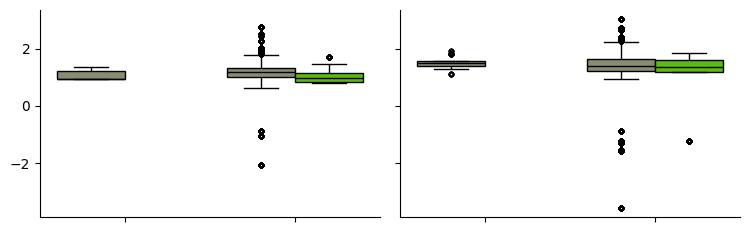

In [21]:
custom_palette = {'diff':    '#8A916F',
                  'diff_ss': '#55D400'}

g = sns.catplot(
    data=dot_fil[dot_fil.orf_type=='uORF'],
    kind='box',
    x='status',
    y='log2FoldChange',
    hue='state',
    col='contrast',
    order=['mORF_uORF', 'dORF_mORF_uORF' ],
    hue_order=['diff','diff_ss'],
    col_order=['mci','mai'],
    palette=custom_palette,
    height=3,
    aspect=1.3,
    legend=False,
    boxprops=dict(edgecolor='black'),whiskerprops=dict(color='black'),capprops=dict(color='black'),medianprops=dict(color='black'),
    flierprops=dict(
        marker='o',
        markeredgecolor='black',
        markersize=3,
        linestyle='none'
    )
)

g.set_titles("")

for ax in g.axes.flatten():
    # ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([]) 
    
# plt.savefig("figures/dte_ss_vs_woss_uORF.png", dpi=300)
# plt.savefig("figures/dte_ss_vs_woss_uORF.pdf")

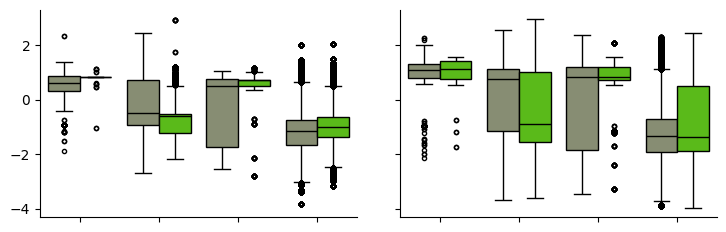

In [23]:
custom_palette = {'diff':    '#8A916F',
                  'diff_ss': '#55D400'}

g = sns.catplot(
    data=dot_fil[dot_fil.orf_type=='mORF'],
    kind='box',
    x='status',
    y='log2FoldChange',
    hue='state',
    col='contrast',
    order=['mORF', 'dORF_mORF', 'mORF_uORF', 'dORF_mORF_uORF' ],
    hue_order=['diff','diff_ss'],
    col_order=['mci','mai'],
    palette=custom_palette,
    height=3,
    aspect=1.3,
    legend=False,
    boxprops=dict(edgecolor='black'),whiskerprops=dict(color='black'),capprops=dict(color='black'),medianprops=dict(color='black'),
    flierprops=dict(
        marker='o',
        markeredgecolor='black',
        markersize=3,
        linestyle='none'
    )
)

g.set_titles("")

for ax in g.axes.flatten():
    # ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([]) 
    
# plt.savefig("figures/dte_ss_vs_woss_mORF.png", dpi=300)
# plt.savefig("figures/dte_ss_vs_woss_mORF.pdf")

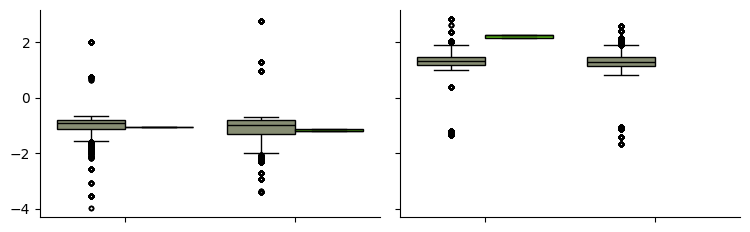

In [25]:
custom_palette = {'diff':    '#8A916F',
                  'diff_ss': '#55D400'}

g = sns.catplot(
    data=dot_fil[dot_fil.orf_type=='dORF'],
    kind='box',
    x='status',
    y='log2FoldChange',
    hue='state',
    col='contrast',
    order=['dORF_mORF', 'dORF_mORF_uORF' ],
    hue_order=['diff','diff_ss'],
    col_order=['mci','mai'],
    palette=custom_palette,
    height=3,
    aspect=1.3,
    legend=False,
    boxprops=dict(edgecolor='black'),whiskerprops=dict(color='black'),capprops=dict(color='black'),medianprops=dict(color='black'),
    flierprops=dict(
        marker='o',
        markeredgecolor='black',
        markersize=3,
        linestyle='none'
    )
)

g.set_titles("")

for ax in g.axes.flatten():
    # ax.set_yscale('log')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([])
    
# plt.savefig("figures/dte_ss_vs_woss_dORF.png", dpi=300)
# plt.savefig("figures/dte_ss_vs_woss_dORF.pdf")

In [89]:
df = pd.read_csv('combined_window_diff_only.bed',sep='\t',header=None)
df = df[[0,1,2,9,4,3,10,7,8]]
df = df.rename(columns={0: 'chr', 1: 'orf_start',
                        2: 'orf_end', 3: 'orf_id', 9:'gid',
                        4: 'misc', 10:'region',7:'ss_start',8:'ss_end'})
df = df.sort_values(['chr','orf_start','orf_end'])
df['ss_type'] = df.region.str.split('_').str[0].str.split('(').str[1]
df['region'] = df.region.str.split('_').str[1].str.split(')').str[0]

df['ss_pos'] = np.where(
    df['ss_type'] == 'donor',
    df['ss_start'] - df['orf_end'],
    df['ss_end'] - df['orf_end']
)

df = df[
    ((df['ss_type'] == 'donor') & (df['ss_pos'] > 0)) |
    ((df['ss_type'] == 'acceptor') & (df['ss_pos'] < 0))
]

df['abs_ss_pos'] = df['ss_pos'].abs()
df['orf_length'] = df['orf_end'] - df['orf_start']

df['contrast'] = df.misc.str.split(',').str[0]
df['orf_type'] = df.misc.str.split(',').str[1]
df['status'] = df.misc.str.split(',').str[2]
df = df[['contrast', 'chr','gid','status','orf_id','orf_type','orf_start','orf_end','orf_length', 'region','ss_type','ss_start','ss_end','ss_pos','abs_ss_pos']]
df_all = df.copy()
df = df[df.abs_ss_pos<=100]

In [90]:
dot_fil['has_ss'] = dot_fil['orf_id'].isin(df['orf_id']).astype(int)

In [91]:
dot_fil['state'] = np.select(
    [
        # differential + splice site
        ((dot_fil['lfsr'] < 0.05) | (dot_fil['padj'] < 0.05)) & (dot_fil['has_ss'] == 1),

        # differential no splice site
        ((dot_fil['lfsr'] < 0.05) | (dot_fil['padj'] < 0.05)) & (dot_fil['has_ss'] == 0),
    ],
    [
        'diff_ss',
        'diff',
    ],
    default='unknown'
)

In [122]:
df[(df.contrast=='mci') & (df.orf_type=='mORF')].gid.nunique()

1589

In [123]:
df[(df.contrast=='mci') & (df.ss_pos>0) & (df.orf_type=='mORF')].gid.nunique()

110

In [47]:
dot_fil.groupby(['contrast','has_ss'])['gid'].size()

contrast  has_ss
mai       0         5012
          1         1137
mci       0         3185
          1          739
Name: gid, dtype: int64

#### Stats ss vs w/o ss

In [68]:
# contrast = ['Mitotic_Cycling - Interphase','Mitotic_Ardot_filt - Interphase']
orfs_upstream = ['mORF_uORF', 'dORF_mORF_uORF']
orfs_main = ['mORF','mORF_uORF', 'dORF_mORF', 'dORF_mORF_uORF']
orfs_downstream = ['dORF_mORF']
cont =['mci','mai']

dte_results = []

for c in cont:
    for s in orfs_upstream:
        g1 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']==s) & (dot_fil.orf_type=='uORF') & (dot_fil.state=='diff_ss')]['log2FoldChange'].dropna()
        g2 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']==s) & (dot_fil.orf_type=='uORF') & (dot_fil.state=='diff')]['log2FoldChange'].dropna()
        
        t_stat, t_pval = stats.ttest_ind(g1, g2) 
    
        dte_results.append({
                'contrast':c,
                'status': s,
                'orf_type': 'uORF',
                'n_diff': len(g1),
                'n_diff_ss': len(g2),
                't_stat': t_stat,
                'p_value': t_pval
            })
    
    for s in orfs_main:
        g1 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']==s) & (dot_fil.orf_type=='mORF') & (dot_fil.state=='diff_ss')]['log2FoldChange'].dropna()
        g2 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']==s) & (dot_fil.orf_type=='mORF') & (dot_fil.state=='diff')]['log2FoldChange'].dropna()
        
        t_stat, t_pval = stats.ttest_ind(g1, g2) 
    
        dte_results.append({
                'contrast':c,
                'status': s,
                'orf_type': 'mORF',
                'n_diff': len(g1),
                'n_diff_ss': len(g2),
                't_stat': t_stat,
                'p_value': t_pval
            })
    
    for s in orfs_downstream:
        g1 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']==s) & (dot_fil.orf_type=='dORF') & (dot_fil.state=='diff_ss')]['log2FoldChange'].dropna()
        g2 = dot_fil[(dot_fil['contrast']==c) & (dot_fil['status']==s) & (dot_fil.orf_type=='dORF') & (dot_fil.state=='diff')]['log2FoldChange'].dropna()
        
        t_stat, t_pval = stats.ttest_ind(g1, g2) 
    
        dte_results.append({
                'contrast':c,
                'status': s,
                'orf_type': 'dORF',
                'n_diff': len(g1),
                'n_diff_ss': len(g2),
                't_stat': t_stat,
                'p_value': t_pval
            })

/tmp/ipykernel_2874063/2073432963.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, t_pval = stats.ttest_ind(g1, g2)
/home/chiga034/projects_limgroup/gab/miniforge3/envs/utils/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [69]:
df_stats_dte = pd.DataFrame(dte_results)

df_stats_dte[df_stats_dte['p_value']<0.05].sort_values(['contrast','status','orf_type'])